# 🎬 Video Periodicity & Contrastive Learning - Kaggle Training & Evaluation Notebook
This notebook handles repository setup, path overrides, SSL (MoCo) / SupCon training, and Anomaly Scoring / Linear Probing evaluation on Kaggle GPUs.

In [1]:
import os
import torch

# 1. Kiểm tra thiết bị GPU
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device count: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

# 2. Đặt thư mục làm việc chính
WORKING_DIR = "/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive"

# Nếu bạn upload source code lên Github hoặc dưới dạng Kaggle Dataset:
# %cd /kaggle/working
# !git clone <your-repo-url> video-periodicity-contrastive

# Chuyển vào thư mục mã nguồn
os.chdir(WORKING_DIR)
print(f"Current working directory: {os.getcwd()}")

CUDA Available: True
Device count: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
Current working directory: /kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive


In [2]:
%%bash
# Cài đặt các gói phụ thuộc (PyAV, OpenCV, Tensorboard/Wandb...)
pip install -r requirements.txt

# Nếu cần chạy smoke test dữ liệu dummy:
# python scripts/make_dummy_data.py --out /kaggle/working/dummy_data --frame-size 112

### 📂 Cấu hình Đường dẫn dữ liệu (Paths Setup)
* **KAGLE_DATA_ROOT**: Thư mục chứa video/frames (Kaggle Input).
* **KAGLE_SPLIT_DIR**: Nơi chứa các file split TXT/CSV (có thể để trong Kaggle Input hoặc `/kaggle/working`).

In [3]:
# Tên Dataset Kaggle của bạn (Thay đổi tương ứng với tên dataset bạn upload lên Kaggle)
DATASET_NAME = "my-video-dataset" 

# Kiểm tra nếu chạy bằng Dữ liệu thật hay Dữ liệu Dummy Smoke Test
USE_DUMMY = False 

if USE_DUMMY:
    DATA_ROOT = "/kaggle/working/dummy_data"
    TRAIN_SSL_SPLIT = "/kaggle/working/dummy_data/splits/unlabeled_train.txt"
    TRAIN_SUPCON_SPLIT = "/kaggle/working/dummy_data/splits/labeled_train.csv"
    VAL_SUPCON_SPLIT = "/kaggle/working/dummy_data/splits/labeled_val.csv"
    NORMAL_SPLIT = "/kaggle/working/dummy_data/splits/normal_train.txt"
    TEST_EVAL_SPLIT = "/kaggle/working/dummy_data/splits/test.csv"
else:
    DATA_ROOT = f"/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/data"
    TRAIN_SSL_SPLIT = f"{DATA_ROOT}/splits/unlabeled_train.txt"
    TRAIN_SUPCON_SPLIT = f"{DATA_ROOT}/splits/labeled_train.csv"
    VAL_SUPCON_SPLIT = f"{DATA_ROOT}/splits/labeled_val.csv"
    NORMAL_SPLIT = f"{DATA_ROOT}/splits/normal_train.txt"
    TEST_EVAL_SPLIT = f"{DATA_ROOT}/splits/test.csv"

BACKBONE = "resnet3d_18"
OUTPUT_DIR = "/kaggle/working/runs"

CHECKPOINT_DIR = "/kaggle/input/datasets/trangdngminh/asd-contrastive-output/runs"

print(f"DATA_ROOT: {DATA_ROOT}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

DATA_ROOT: /kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/data
OUTPUT_DIR: /kaggle/working/runs


## 🚀 1. Self-Supervised Learning (SSL - MoCo) Pretraining
Chạy MoCo v2 với Speed Warp và Frame Shuffle. 
Sử dụng CLI overrides `--opts` để ghi đè cấu hình trong `configs/ssl_moco.yaml` mà không cần sửa file trực tiếp[cite: 1, 2].

In [4]:
# import subprocess

# print(f"🚀 Executing SSL MoCo Training...")

# # Chạy trực tiếp trong Cell Python (không dùng %%bash)
# ssl_cmd = f"""
# python -m torch.distributed.run --nproc_per_node=gpu train.py --config configs/ssl_moco.yaml --opts backbone.name={BACKBONE} backbone.pretrained=True data.root={DATA_ROOT} data.train_split={TRAIN_SSL_SPLIT} data.num_workers=2 data.clips_per_video=4 output_dir={OUTPUT_DIR} optim.batch_size=8 optim.epochs=30
# """

# subprocess.run(ssl_cmd, shell=True, check=True)

## 🎯 2. Supervised Contrastive Learning (SupCon) Training
Chạy SupCon với nhãn hành vi (`0 = non-ASD`, `1 = ASD/stimming`).

In [5]:
# import subprocess

# print(f"🎯 Executing SupCon Training...")

# supcon_cmd = f"""
# python -m torch.distributed.run --nproc_per_node=gpu train.py --config configs/supcon.yaml --opts backbone.name={BACKBONE} backbone.pretrained=True data.root={DATA_ROOT} data.train_split={TRAIN_SUPCON_SPLIT} data.num_workers=2 output_dir={OUTPUT_DIR} optim.batch_size=8 optim.epochs=30
# """

# subprocess.run(supcon_cmd, shell=True, check=True)

## 🎯 3. Self-Supervised Synthetic Periodicity Injection (SPI) Training
Chạy SPI: pretext task là Synthetic Periodicity Injection the positive/negative structure comes from synthesized periodic clips with a *known* cycle length.

In [6]:
import subprocess

print(f"🎯 Executing SPI Training...")

spi_cmd = f"""
python -m torch.distributed.run --nproc_per_node=gpu train.py --config configs/spi_periodicity.yaml --opts backbone.name={BACKBONE} backbone.pretrained=True data.root={DATA_ROOT} data.train_split={NORMAL_SPLIT} data.num_workers=2 data.clips_per_video=8 output_dir={OUTPUT_DIR} optim.batch_size=8 optim.epochs=30
"""

subprocess.run(spi_cmd, shell=True, check=True)

🎯 Executing SPI Training...



*****************************************
Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
*****************************************


[SPIDataset] 45 videos -> 339 windows (clips_per_video=8); 15/45 (33.3%) too short to avoid overlap entirely.
Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:00<00:00, 220MB/s]


[SPIDataset] 45 videos -> 339 windows (clips_per_video=8); 15/45 (33.3%) too short to avoid overlap entirely.
[step 1] loss=6.2427 | lr=0.0002 | spicon_contrastive=4.8020 | spicon_period_reg=2.4485 | moco_infonce=0.4330
[spi] epoch 0 done in 265.8s, avg_loss=5.6122
[step 21] loss=5.2184 | lr=0.0040 | spicon_contrastive=3.1518 | spicon_period_reg=0.9894 | moco_infonce=3.1438
[spi] epoch 1 done in 246.9s, avg_loss=5.1743
[step 41] loss=5.8434 | lr=0.0078 | spicon_contrastive=3.1427 | spicon_period_reg=0.3207 | moco_infonce=5.0808
[spi] epoch 2 done in 256.8s, avg_loss=5.4410
[step 61] loss=5.0611 | lr=0.0116 | spicon_contrastive=3.1406 | spicon_period_reg=0.1852 | moco_infonce=3.6559
[spi] epoch 3 done in 227.7s, avg_loss=5.5024
[step 81] loss=5.1219 | lr=0.0154 | spicon_contrastive=3.1408 | spicon_period_reg=0.1727 | moco_infonce=3.7893
[spi] epoch 4 done in 236.6s, avg_loss=5.3713
[step 101] loss=5.6100 | lr=0.0192 | spicon_contrastive=3.1413 | spicon_period_reg=0.2807 | moco_infonce=4

CompletedProcess(args='\npython -m torch.distributed.run --nproc_per_node=gpu train.py --config configs/spi_periodicity.yaml --opts backbone.name=resnet3d_18 backbone.pretrained=True data.root=/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/data data.train_split=/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/data/splits/normal_train.txt data.num_workers=2 data.clips_per_video=8 output_dir=/kaggle/working/runs optim.batch_size=8 optim.epochs=30\n', returncode=0)

## 📊 4. Downstream Evaluation: Anomaly Scoring (K-Centroids)
- **Stage 2**: Mining K-Centroids trên tập clips bình thường (`normal_split`)[cite: 1, 3].
- **Stage 3**: Inference cửa sổ trượt (sliding window) trên tập `test_split` và tính AUC-ROC / EER / FAR-ratio[cite: 1, 3].

In [7]:
# import subprocess

# print(f"📊 Executing Anomaly Scoring - SSL Evaluation...")

# eval_anomaly_ssl_cmd = f"""
# python eval.py --config configs/eval.yaml --mode anomaly_scoring --opts data.root={DATA_ROOT} data.num_workers=2 backbone.name={BACKBONE} output_dir={OUTPUT_DIR} checkpoint_path={OUTPUT_DIR}/ssl_moco/ckpt_last.pth eval.centroids.k=20 eval.centroids.normal_split={NORMAL_SPLIT} eval.centroids.save_path={OUTPUT_DIR}/ssl_moco/centroids.pth eval.test_split={TEST_EVAL_SPLIT} visualize.out_dir={OUTPUT_DIR}/ssl_moco/plots
# """

# subprocess.run(eval_anomaly_ssl_cmd, shell=True, check=True)

In [8]:
# import subprocess

# print(f"📊 Executing Anomaly Scoring - SupCon Evaluation...")

# eval_anomaly_supcon_cmd = f"""
# python eval.py --config configs/eval.yaml --mode anomaly_scoring --opts data.root={DATA_ROOT} data.num_workers=2 backbone.name={BACKBONE} output_dir={OUTPUT_DIR} checkpoint_path={OUTPUT_DIR}/supcon/ckpt_last.pth eval.centroids.k=20 eval.centroids.normal_split={NORMAL_SPLIT} eval.centroids.save_path={OUTPUT_DIR}/supcon/centroids.pth eval.test_split={TEST_EVAL_SPLIT} visualize.out_dir={OUTPUT_DIR}/supcon/plots
# """

# subprocess.run(eval_anomaly_supcon_cmd, shell=True, check=True)

In [9]:
import subprocess

print(f"📊 Executing Anomaly Scoring - SPI Evaluation...")

eval_anomaly_spi_cmd = f"""
python eval.py --config configs/eval.yaml --mode anomaly_scoring --opts data.root={DATA_ROOT} data.num_workers=2 backbone.name={BACKBONE} spi.training_mode=in_batch output_dir={OUTPUT_DIR} checkpoint_path={OUTPUT_DIR}/spi_periodicity/ckpt_last.pth eval.centroids.k=20 eval.centroids.normal_split={NORMAL_SPLIT} eval.centroids.save_path={OUTPUT_DIR}/spi_periodicity/centroids.pth eval.test_split={TEST_EVAL_SPLIT} visualize.out_dir={OUTPUT_DIR}/spi_periodicity/plots
"""

subprocess.run(eval_anomaly_spi_cmd, shell=True, check=True)

📊 Executing Anomaly Scoring - SPI Evaluation...
[eval] mined 20 centroids from 45 normal clips -> /kaggle/working/runs/spi_periodicity/centroids.pth
[eval] frame-level metrics over 12 videos: {'eer': 0.4130370330814461, 'far_ratio': 0.0, 'micro_auc_roc': 0.6024786325896608, 'macro_auc_roc': 0.6737995171204262}
[eval] results saved to /kaggle/working/runs/video_periodicity_contrastive/anomaly_scoring_results.json


CompletedProcess(args='\npython eval.py --config configs/eval.yaml --mode anomaly_scoring --opts data.root=/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/data data.num_workers=2 backbone.name=resnet3d_18 spi.training_mode=in_batch output_dir=/kaggle/working/runs checkpoint_path=/kaggle/working/runs/spi_periodicity/ckpt_last.pth eval.centroids.k=20 eval.centroids.normal_split=/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/data/splits/normal_train.txt eval.centroids.save_path=/kaggle/working/runs/spi_periodicity/centroids.pth eval.test_split=/kaggle/input/datasets/trangdngminh/asd-contrastive-data/asd-contrastive/data/splits/test.csv visualize.out_dir=/kaggle/working/runs/spi_periodicity/plots\n', returncode=0)

## 📈 5. Downstream Evaluation: Linear Probing
Đóng đóng băng (freeze) backbone encoder và chỉ train `ClassificationHead`[cite: 1, 3].

In [10]:
# import subprocess

# print(f"📈 Executing Linear Probing Evaluation...")

# eval_linear_cmd = f"""
# python eval.py --config configs/eval.yaml --mode linear_probing --opts data.root={DATA_ROOT} data.num_workers=2 backbone.name={BACKBONE} checkpoint_path={OUTPUT_DIR}/supcon/ckpt_last.pth eval.linear_probe.train_split={TRAIN_SUPCON_SPLIT} eval.linear_probe.val_split={VAL_SUPCON_SPLIT} eval.linear_probe.batch_size=16 eval.linear_probe.epochs=5
# """

# subprocess.run(eval_linear_cmd, shell=True, check=True)

In [11]:
# import os
# from PIL import Image
# import matplotlib.pyplot as plt

# PLOT_DIR_SSL = "/kaggle/working/runs/ssl_moco/plots"

# if os.path.exists(PLOT_DIR_SSL):
#     plot_files = [f for f in os.listdir(PLOT_DIR_SSL) if f.endswith(('.png', '.jpg'))]
#     print(f"Found {len(plot_files)} generated plots in {PLOT_DIR_SSL}:")
    
#     for p in plot_files:
#         img_path = os.path.join(PLOT_DIR_SSL, p)
#         img = Image.open(img_path)
#         plt.figure(figsize=(8, 4))
#         plt.imshow(img)
#         plt.title(p)
#         plt.axis('off')
#         plt.show()
# else:
#     print("No plots folder found yet.")

Found 13 generated plots in /kaggle/working/runs/spi_periodicity/plots:


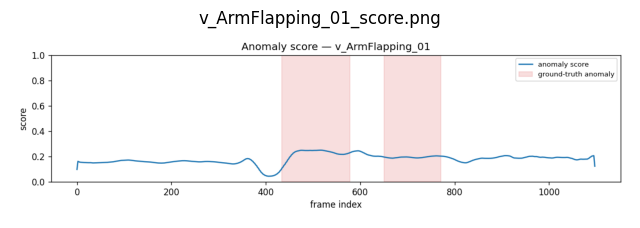

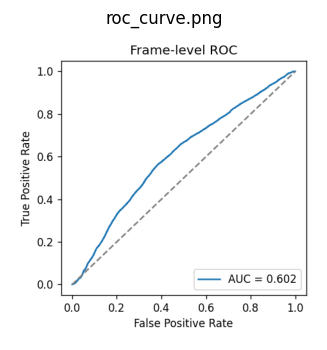

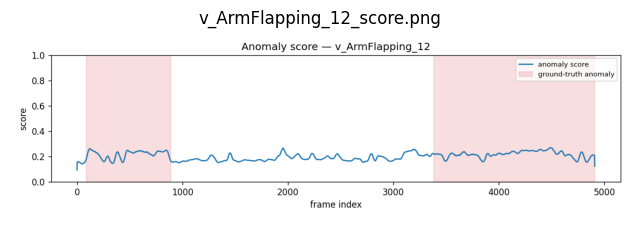

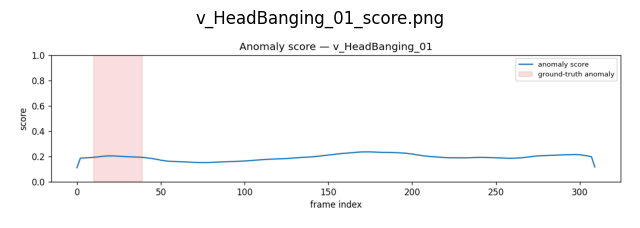

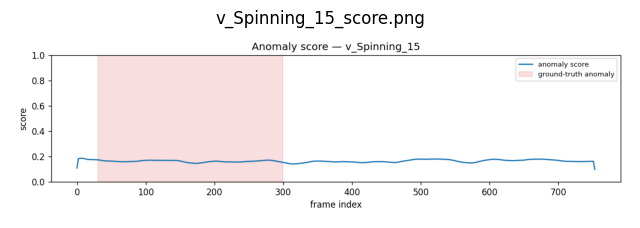

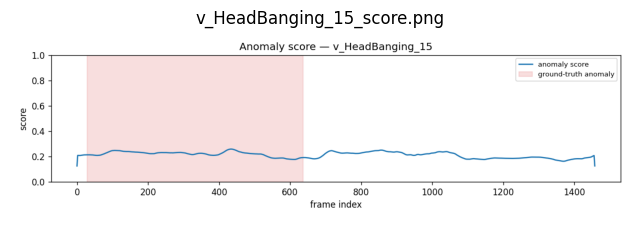

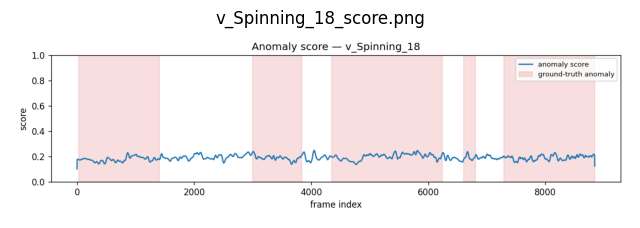

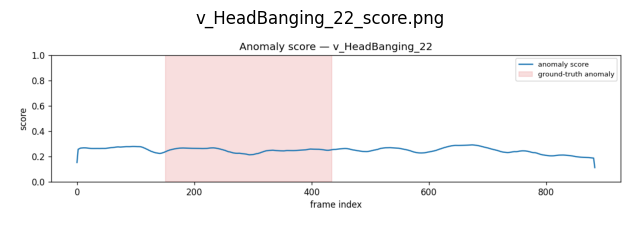

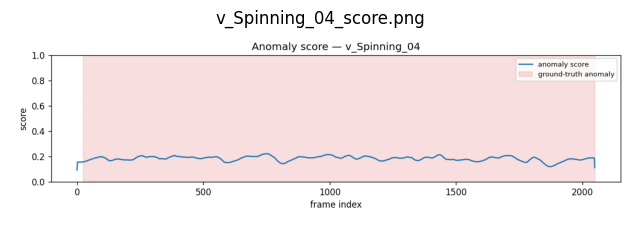

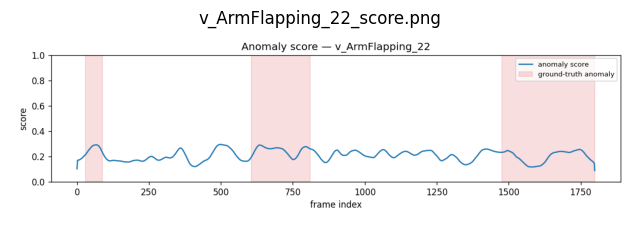

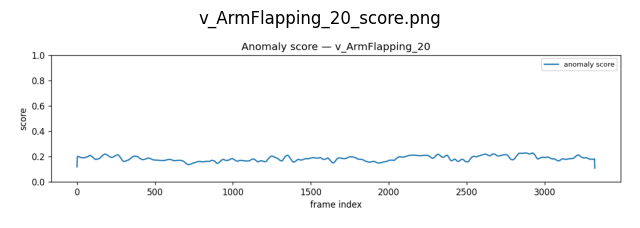

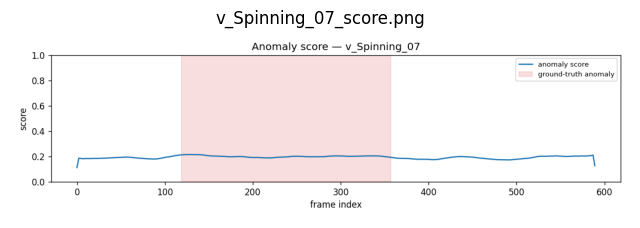

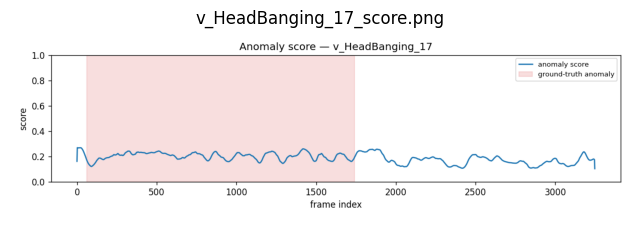

In [12]:
import os
from PIL import Image
import matplotlib.pyplot as plt

PLOT_DIR_SPI = "/kaggle/working/runs/spi_periodicity/plots"

if os.path.exists(PLOT_DIR_SPI):
    plot_files = [f for f in os.listdir(PLOT_DIR_SPI) if f.endswith(('.png', '.jpg'))]
    print(f"Found {len(plot_files)} generated plots in {PLOT_DIR_SPI}:")
    
    for p in plot_files:
        img_path = os.path.join(PLOT_DIR_SPI, p)
        img = Image.open(img_path)
        plt.figure(figsize=(8, 4))
        plt.imshow(img)
        plt.title(p)
        plt.axis('off')
        plt.show()
else:
    print("No plots folder found yet.")